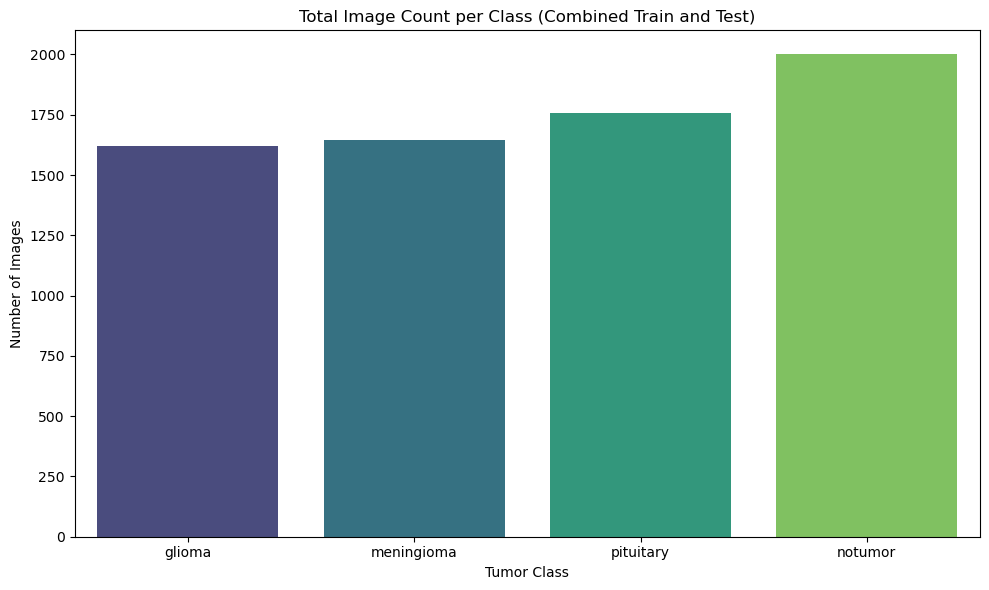


Width Statistics:
count    7023.000000
mean      445.891499
std       132.328035
min       150.000000
25%       393.000000
50%       512.000000
75%       512.000000
max      1920.000000
Name: Width, dtype: float64

Height Statistics:
count    7023.000000
mean      448.346860
std       126.282922
min       168.000000
25%       403.500000
50%       512.000000
75%       512.000000
max      1446.000000
Name: Height, dtype: float64

Size Statistics by Class:

GLIOMA Class:
Width stats:
count    1621.0
mean      512.0
std         0.0
min       512.0
25%       512.0
50%       512.0
75%       512.0
max       512.0
Name: Width, dtype: float64
Height stats:
count    1621.0
mean      512.0
std         0.0
min       512.0
25%       512.0
50%       512.0
75%       512.0
max       512.0
Name: Height, dtype: float64

MENINGIOMA Class:
Width stats:
count    1645.000000
mean      483.133131
std        90.420556
min       174.000000
25%       512.000000
50%       512.000000
75%       512.000000
max    

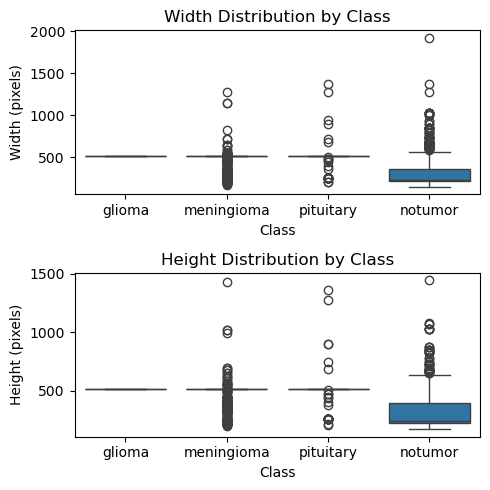

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
import numpy as np

# Base dataset path
base_path = "../data/raw"

# Labels to analyze
labels = ["glioma", "meningioma", "pituitary", "notumor"]

# Function to count images per class (combined train and test)
def count_images(base_path, labels):
    data = []
    for label in labels:
        total_count = 0
        # Count both train and test images
        for subset in ["train", "test"]:
            path = os.path.join(base_path, subset, label)
            total_count += len(os.listdir(path))
        data.append({"Class": label, "Count": total_count})
    return pd.DataFrame(data)

# Function to analyze image dimensions
def analyze_image_sizes(base_path, labels):
    width_list = []
    height_list = []
    size_data = []
    
    for label in labels:
        for subset in ["train", "test"]:
            path = os.path.join(base_path, subset, label)
            for img_name in os.listdir(path):
                img_path = os.path.join(path, img_name)
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        width_list.append(width)
                        height_list.append(height)
                        size_data.append({
                            "Class": label,
                            "Width": width,
                            "Height": height
                        })
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")
    
    return pd.DataFrame(size_data)

# Get image counts
df_counts = count_images(base_path, labels)

# Plot counts - fixed deprecation warning
plt.figure(figsize=(5, 5))
sns.barplot(x="Class", y="Count", hue="Class", data=df_counts, palette="viridis", legend=False)
plt.title("Total Image Count per Class (Combined Train and Test)")
plt.ylabel("Number of Images")
plt.xlabel("Tumor Class")
plt.tight_layout()
plt.show()

# Analyze image sizes
df_sizes = analyze_image_sizes(base_path, labels)

# Use describe() for better statistics
width_stats = df_sizes['Width'].describe()
height_stats = df_sizes['Height'].describe()

print("\nWidth Statistics:")
print(width_stats)

print("\nHeight Statistics:")
print(height_stats)

# Class-specific statistics
print("\nSize Statistics by Class:")
for label in labels:
    class_df = df_sizes[df_sizes['Class'] == label]
    print(f"\n{label.upper()} Class:")
    print("Width stats:")
    print(class_df['Width'].describe())
    print("Height stats:")
    print(class_df['Height'].describe())

# Plot image size distribution
plt.figure(figsize=(5, 5))
plt.subplot(2, 1, 1)
sns.boxplot(x="Class", y="Width", data=df_sizes)
plt.title("Width Distribution by Class")
plt.ylabel("Width (pixels)")

plt.subplot(2, 1, 2)
sns.boxplot(x="Class", y="Height", data=df_sizes)
plt.title("Height Distribution by Class")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()